# Car Price Exploratory Data Analysis

An exploratory data analysis (EDA) of used-car listings, examining how selling price relates to a car's age, mileage, fuel type, ownership history, and engine specifications.

**Dataset:** [Vehicle dataset from CarDekho](https://www.kaggle.com/datasets/nehalbirla/vehicle-dataset-from-cardekho) (used-car listings, India)
**Tools:** Python · Pandas · NumPy · Matplotlib · Seaborn

---

## Table of Contents
1. [Import Libraries](#1)
2. [Load Dataset](#2)
3. [Initial Inspection](#3)
4. [Missing Value Analysis](#4)
5. [Data Cleaning](#5)
6. [Univariate Analysis](#6)
7. [Bivariate Analysis](#7)
8. [Correlation Analysis](#8)
9. [Outlier Detection](#9)
10. [Key Insights & Conclusion](#10)


## 1. Import Libraries <a id='1'></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 11

# Folder where chart images are saved (also used in the README)
IMAGES_DIR = '../images'
os.makedirs(IMAGES_DIR, exist_ok=True)


## 2. Load Dataset <a id='2'></a>

The raw CarDekho listings (`data/car_data_raw.csv`) were de-duplicated, stripped of
"Test Drive Car" listings (not real sales), and had their unit-suffixed numeric
columns (`mileage`, `engine`, `max_power`) converted to plain numbers. The result
is `data/car_data.csv`, which is what this notebook loads.

In [2]:
df = pd.read_csv('../data/car_data.csv')

# Extract the brand from the full car name (its first word)
df['brand'] = df['name'].str.split().str[0]

print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')


Shape: (6712, 13)
Columns: ['name', 'year', 'selling_price', 'km_driven', 'fuel', 'seller_type', 'transmission', 'owner', 'mileage(km/ltr/kg)', 'engine', 'max_power', 'seats', 'brand']


## 3. Initial Inspection <a id='3'></a>

In [3]:
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage(km/ltr/kg),engine,max_power,seats,brand
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248.0,74.00,5.0,Maruti
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498.0,103.52,5.0,Skoda
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1497.0,78.00,5.0,Honda
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1396.0,90.00,5.0,Hyundai
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1298.0,88.20,5.0,Maruti


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6712 entries, 0 to 6711
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   name                6712 non-null   str    
 1   year                6712 non-null   int64  
 2   selling_price       6712 non-null   int64  
 3   km_driven           6712 non-null   int64  
 4   fuel                6712 non-null   str    
 5   seller_type         6712 non-null   str    
 6   transmission        6712 non-null   str    
 7   owner               6712 non-null   str    
 8   mileage(km/ltr/kg)  6712 non-null   float64
 9   engine              6712 non-null   float64
 10  max_power           6712 non-null   float64
 11  seats               6712 non-null   float64
 12  brand               6712 non-null   object 
dtypes: float64(4), int64(3), object(1), str(5)
memory usage: 681.8+ KB


In [5]:
df.describe().round(2)

,year,selling_price,km_driven,mileage(km/ltr/kg),engine,max_power,seats
count,6712.00,6712.00,6712.00,6712.00,6712.00,6712.00,6712.00
mean,2013.61,523497.58,73442.12,19.47,1430.76,87.71,5.43
std,3.90,509257.11,58702.80,4.05,493.57,31.66,0.98
min,1994.00,29999.00,1.00,0.00,624.00,32.80,2.00
25%,2011.00,250000.00,38000.00,16.80,1197.00,67.10,5.00
50%,2014.00,420000.00,68559.50,19.44,1248.00,81.83,5.00
75%,2017.00,650000.00,100000.00,22.51,1498.00,100.00,5.00
max,2020.00,10000000.00,2360457.00,42.00,3604.00,400.00,14.00


In [6]:
print('Data type distribution:')
print(df.dtypes.value_counts())


Data type distribution:
str        5
float64    4
int64      3
object     1
Name: count, dtype: int64


## 4. Missing Value Analysis <a id='4'></a>

In [7]:
missing = df.isnull().sum()
print('Missing values per column:')
print(missing[missing > 0] if missing.sum() > 0 else 'No missing values found')


Missing values per column:
No missing values found


**Insight:** the dataset has no missing values left — they were already
removed during the cleaning step described above.

## 5. Data Cleaning <a id='5'></a>

In [8]:
before = df.shape[0]

# 1) Drop unrealistic odometer readings: a passenger car reporting >= 500,000 km
#    driven is almost always a data-entry error.
df = df[df['km_driven'] < 500000]

# 2) Use the IQR method to cap extreme selling_price outliers. A handful of
#    luxury listings (BMW, Mercedes, Audi, Land Rover, ...) sit far above the
#    rest of the market and, if kept, compress every chart below into an
#    unreadable spike near zero.
q1, q3 = df['selling_price'].quantile([0.25, 0.75])
iqr = q3 - q1
upper_bound = q3 + 1.5 * iqr
df = df[df['selling_price'] <= upper_bound].reset_index(drop=True)

print(f'Rows before cleaning : {before}')
print(f'Rows after cleaning  : {df.shape[0]}')
print(f'Rows removed         : {before - df.shape[0]}')
print(f'Price IQR upper bound: {upper_bound:,.0f}')


Rows before cleaning : 6712
Rows after cleaning  : 6406
Rows removed         : 306
Price IQR upper bound: 1,250,000


**Insight**
- 306 rows (4.6%) were removed: a small number of unrealistic odometer readings, plus the top end of the price range — a handful of premium listings (BMW, Mercedes-Benz, Audi, Land Rover, etc.) that sat far outside the bulk of the market and would otherwise compress every chart below into an unreadable spike near zero.
- The price cap (₹1,250,000) was not picked by hand — it's the standard IQR upper bound (`Q3 + 1.5 × IQR`), so the cutoff is statistically justified rather than arbitrary.

## 6. Univariate Analysis <a id='6'></a>

### Selling Price — Summary Statistics

In [9]:
sp = df['selling_price']
print(f'  Min      : {sp.min():,.0f}')
print(f'  Q1       : {sp.quantile(0.25):,.0f}')
print(f'  Median   : {sp.median():,.0f}')
print(f'  Mean     : {sp.mean():,.0f}')
print(f'  Q3       : {sp.quantile(0.75):,.0f}')
print(f'  Max      : {sp.max():,.0f}')
print(f'  Std      : {sp.std():,.0f}')
skew = sp.skew()
print(f'  Skewness : {skew:.2f} -> {"Right-skewed" if skew > 0.5 else "Approximately symmetric"}')


  Min      : 29,999
  Q1       : 250,000
  Median   : 400,000
  Mean     : 443,684
  Q3       : 600,000
  Max      : 1,250,000
  Std      : 253,022
  Skewness : 0.69 -> Right-skewed


### Distribution of Selling Price

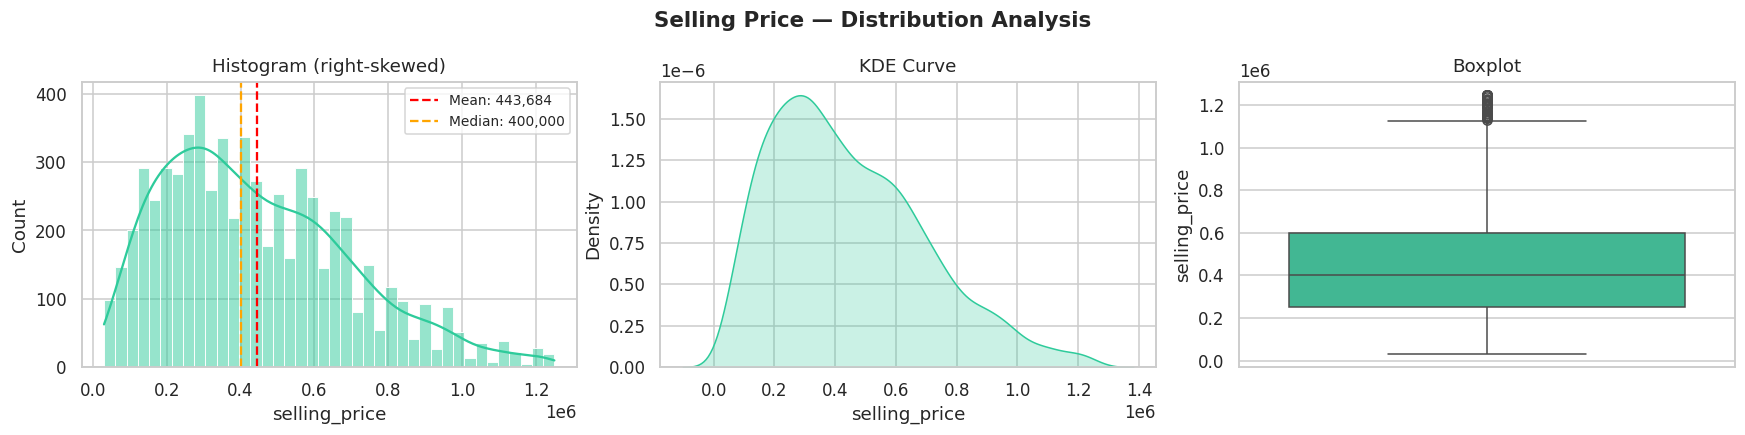

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Selling Price — Distribution Analysis', fontsize=14, fontweight='bold')

sns.histplot(df['selling_price'], ax=axes[0], color='#2ECB9B', kde=True, bins=40)
axes[0].set_title('Histogram (right-skewed)')
axes[0].axvline(sp.mean(),   color='red',    linestyle='--', label=f'Mean: {sp.mean():,.0f}')
axes[0].axvline(sp.median(), color='orange', linestyle='--', label=f'Median: {sp.median():,.0f}')
axes[0].legend(fontsize=9)

sns.kdeplot(df['selling_price'], ax=axes[1], fill=True, color='#2ECB9B')
axes[1].set_title('KDE Curve')

sns.boxplot(y=df['selling_price'], ax=axes[2], color='#2ECB9B')
axes[2].set_title('Boxplot')

plt.tight_layout()
plt.savefig(f'{IMAGES_DIR}/price_distribution.png', bbox_inches='tight')
plt.show()


**Insight**
- `selling_price` is right-skewed (skew = 0.69): most cars sell well below the mean.
- The median price is ₹400,000, about ₹44,000 below the mean (₹443,684) — a classic sign that a thinner group of higher-priced listings pulls the average up.
- The boxplot confirms a long upper tail, with the bulk of listings clustering between ₹150,000 and ₹650,000.

### Log Transformation

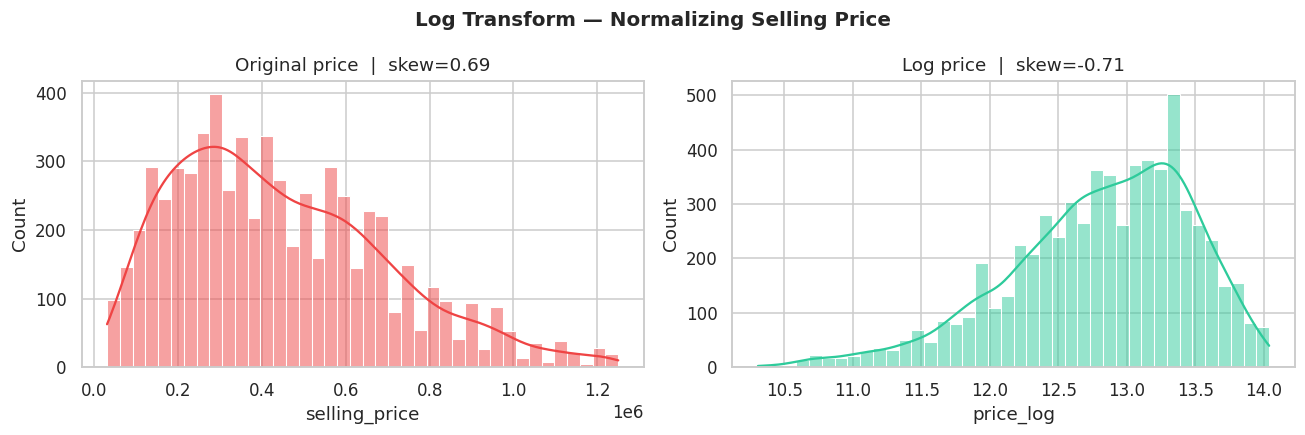

In [11]:
df['price_log'] = np.log1p(df['selling_price'])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Log Transform — Normalizing Selling Price', fontsize=13, fontweight='bold')

sns.histplot(df['selling_price'], ax=axes[0], color='#EF4444', bins=40, kde=True)
axes[0].set_title(f'Original price  |  skew={df["selling_price"].skew():.2f}')

sns.histplot(df['price_log'], ax=axes[1], color='#2ECB9B', bins=40, kde=True)
axes[1].set_title(f'Log price  |  skew={df["price_log"].skew():.2f}')

plt.tight_layout()
plt.savefig(f'{IMAGES_DIR}/log_transform.png', bbox_inches='tight')
plt.show()


**Insight**
- The log transform (`log1p`) is meant to pull in a long right tail, but here it slightly *overcorrects* — skew flips from +0.69 to -0.71.
- That's a direct side-effect of the cleaning in Section 5: with the most extreme high-price listings already capped using IQR, there's no long tail left to fix, so log-transforming starts introducing a mild left skew instead. A useful reminder to check skew *after* a transform rather than applying it automatically.

### Top 10 Car Brands by Listing Count

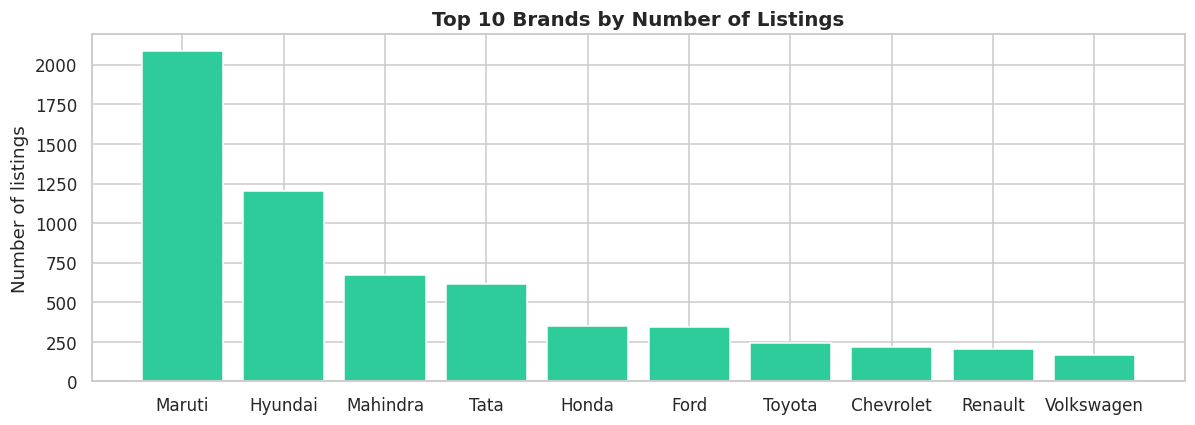

In [12]:
top10_brands = df['brand'].value_counts().head(10)

plt.figure(figsize=(11, 4))
plt.bar(top10_brands.index, top10_brands.values, color='#2ECB9B', edgecolor='white')
plt.title('Top 10 Brands by Number of Listings', fontsize=13, fontweight='bold')
plt.ylabel('Number of listings')
plt.tight_layout()
plt.savefig(f'{IMAGES_DIR}/top10_brands.png', bbox_inches='tight')
plt.show()


**Insight**
- Maruti dominates the listings (~2,090), more than the next two brands (Hyundai, Mahindra) combined.
- Maruti and Hyundai together account for roughly half of all listings — unsurprising, since they are consistently the two best-selling new-car brands in India, which directly feeds the used-car supply.

## 7. Bivariate Analysis <a id='7'></a>

### Fuel Type vs. Price

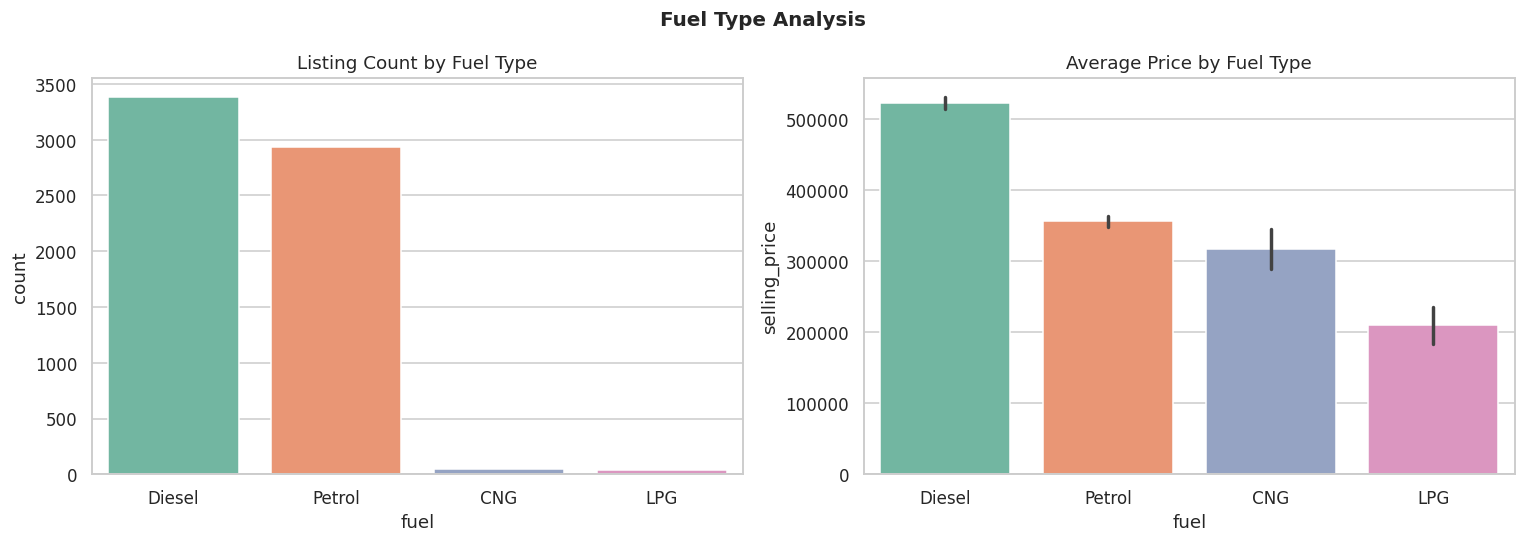

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Fuel Type Analysis', fontsize=13, fontweight='bold')

fuel_order = df['fuel'].value_counts().index
sns.countplot(data=df, x='fuel', order=fuel_order, palette='Set2', ax=axes[0])
axes[0].set_title('Listing Count by Fuel Type')

fuel_price_order = df.groupby('fuel')['selling_price'].mean().sort_values(ascending=False).index
sns.barplot(data=df, x='fuel', y='selling_price', order=fuel_price_order, palette='Set2', ax=axes[1])
axes[1].set_title('Average Price by Fuel Type')

plt.tight_layout()
plt.savefig(f'{IMAGES_DIR}/fuel_type_analysis.png', bbox_inches='tight')
plt.show()


**Insight**
- Diesel and Petrol dominate the listings; CNG and LPG together make up under 2% of the market.
- Diesel cars command the highest average price (~₹525,000) — about 48% more than Petrol (~₹355,000) — likely because diesel engines are more common in larger, pricier vehicle segments (SUVs, sedans) than in entry-level hatchbacks.

### Ownership History vs. Price

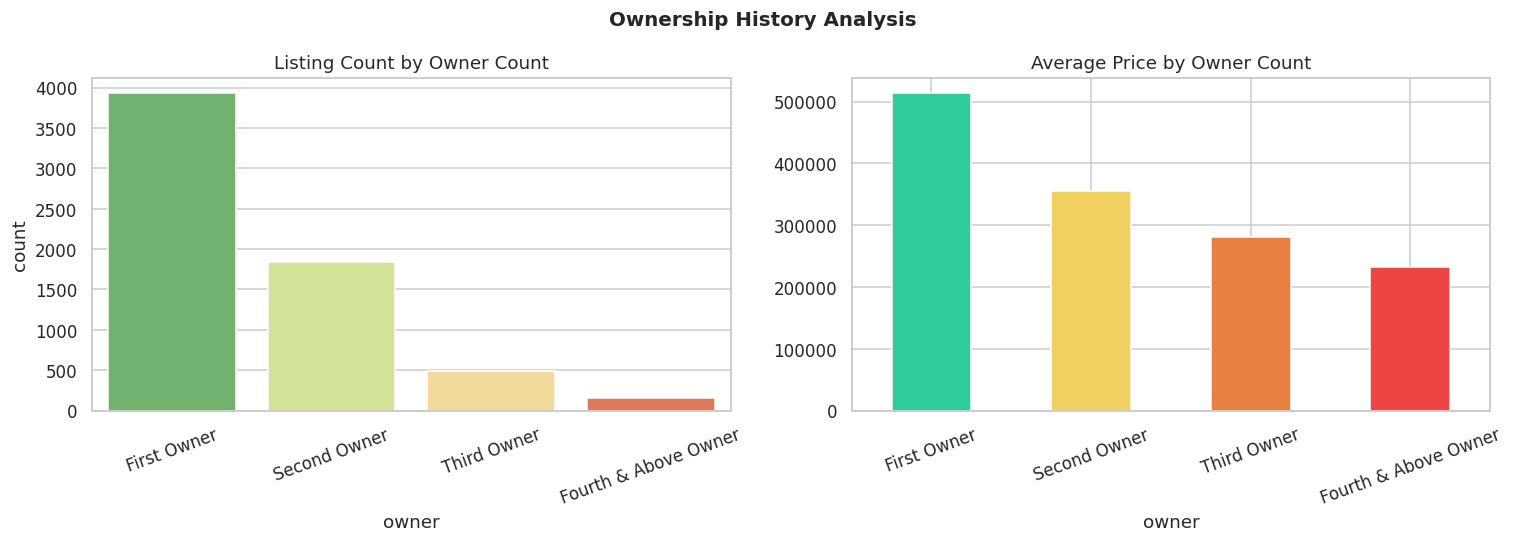

In [14]:
owner_order = ['First Owner', 'Second Owner', 'Third Owner', 'Fourth & Above Owner']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Ownership History Analysis', fontsize=13, fontweight='bold')

sns.countplot(data=df, x='owner', order=owner_order, palette='RdYlGn_r', ax=axes[0])
axes[0].set_title('Listing Count by Owner Count')
axes[0].tick_params(axis='x', rotation=20)

owner_avg = df.groupby('owner')['selling_price'].mean().reindex(owner_order)
owner_avg.plot(kind='bar', ax=axes[1], color=['#2ECB9B','#F0D060','#E88040','#EF4444'], edgecolor='white')
axes[1].set_title('Average Price by Owner Count')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig(f'{IMAGES_DIR}/owner_analysis.png', bbox_inches='tight')
plt.show()


**Insight**
- First-owner cars make up the majority of listings (~62%) and sell for the highest average price (~₹510,000).
- Average price falls in lock-step with each additional owner — Second (~₹355,000), Third (~₹280,000), Fourth & Above (~₹240,000) — roughly a 53% drop in value from first owner to fourth.

### Kilometers Driven vs. Price

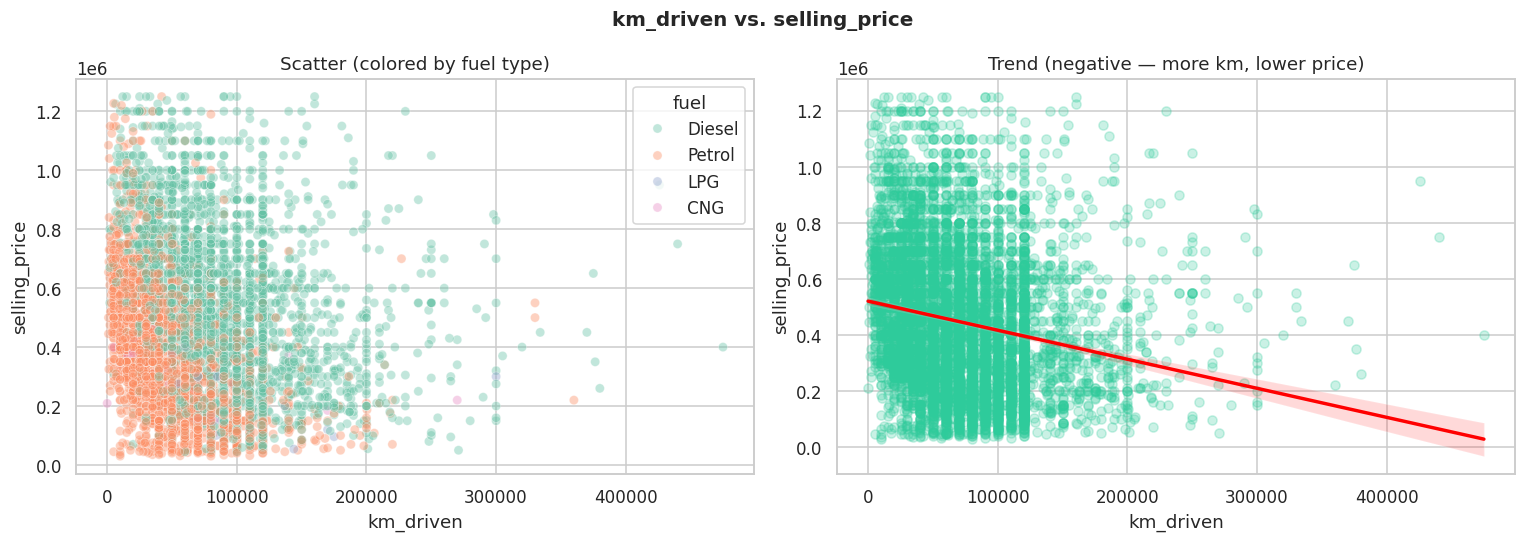

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('km_driven vs. selling_price', fontsize=13, fontweight='bold')

sns.scatterplot(data=df, x='km_driven', y='selling_price',
                hue='fuel', palette='Set2', alpha=0.4, ax=axes[0])
axes[0].set_title('Scatter (colored by fuel type)')

sns.regplot(data=df, x='km_driven', y='selling_price',
            scatter_kws={'alpha':0.25,'color':'#2ECB9B'},
            line_kws={'color':'red'}, ax=axes[1])
axes[1].set_title('Trend (negative — more km, lower price)')

plt.tight_layout()
plt.savefig(f'{IMAGES_DIR}/km_driven_vs_price.png', bbox_inches='tight')
plt.show()


**Insight**
- There's a visible negative relationship between distance driven and price, though the spread is wide — `km_driven` alone correlates with price at only -0.20.
- Diesel listings (green) extend much further along the x-axis than Petrol (orange), consistent with diesel being more common on higher-mileage vehicles like SUVs and family sedans that rack up more kilometers over their lifetime.

### Top Features vs. Price (Regression Plots)

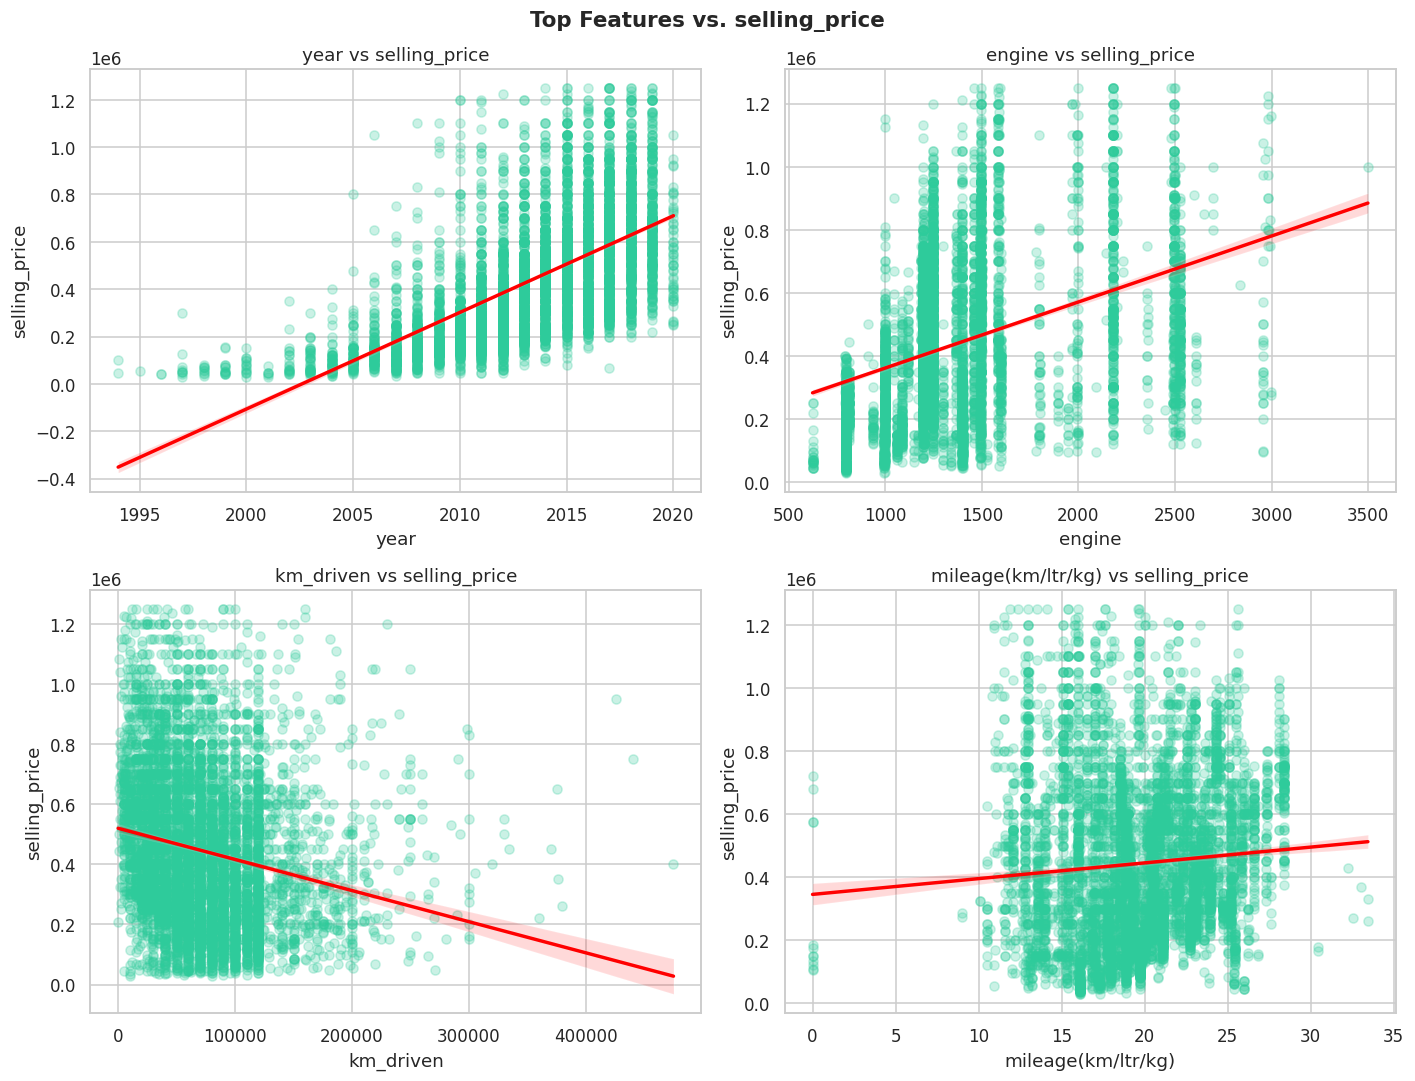

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
fig.suptitle('Top Features vs. selling_price', fontsize=14, fontweight='bold')

feature_cols = ['year', 'engine', 'km_driven', 'mileage(km/ltr/kg)']

for ax, xcol in zip(axes.flatten(), feature_cols):
    sns.regplot(data=df, x=xcol, y='selling_price', ax=ax,
                scatter_kws={'alpha':0.25, 'color':'#2ECB9B'},
                line_kws={'color':'red'})
    ax.set_title(f'{xcol} vs selling_price')

plt.tight_layout()
plt.savefig(f'{IMAGES_DIR}/regplots.png', bbox_inches='tight')
plt.show()


**Insight**
- `year` has by far the strongest linear relationship with price (corr = 0.63) — newer cars are reliably worth more.
- `engine` shows a moderate positive trend (corr = 0.38); `km_driven` a moderate negative one (corr = -0.20).
- `mileage(km/ltr/kg)` is nearly flat (corr = 0.08) — fuel efficiency alone says very little about resale price.

### Pairwise Relationships

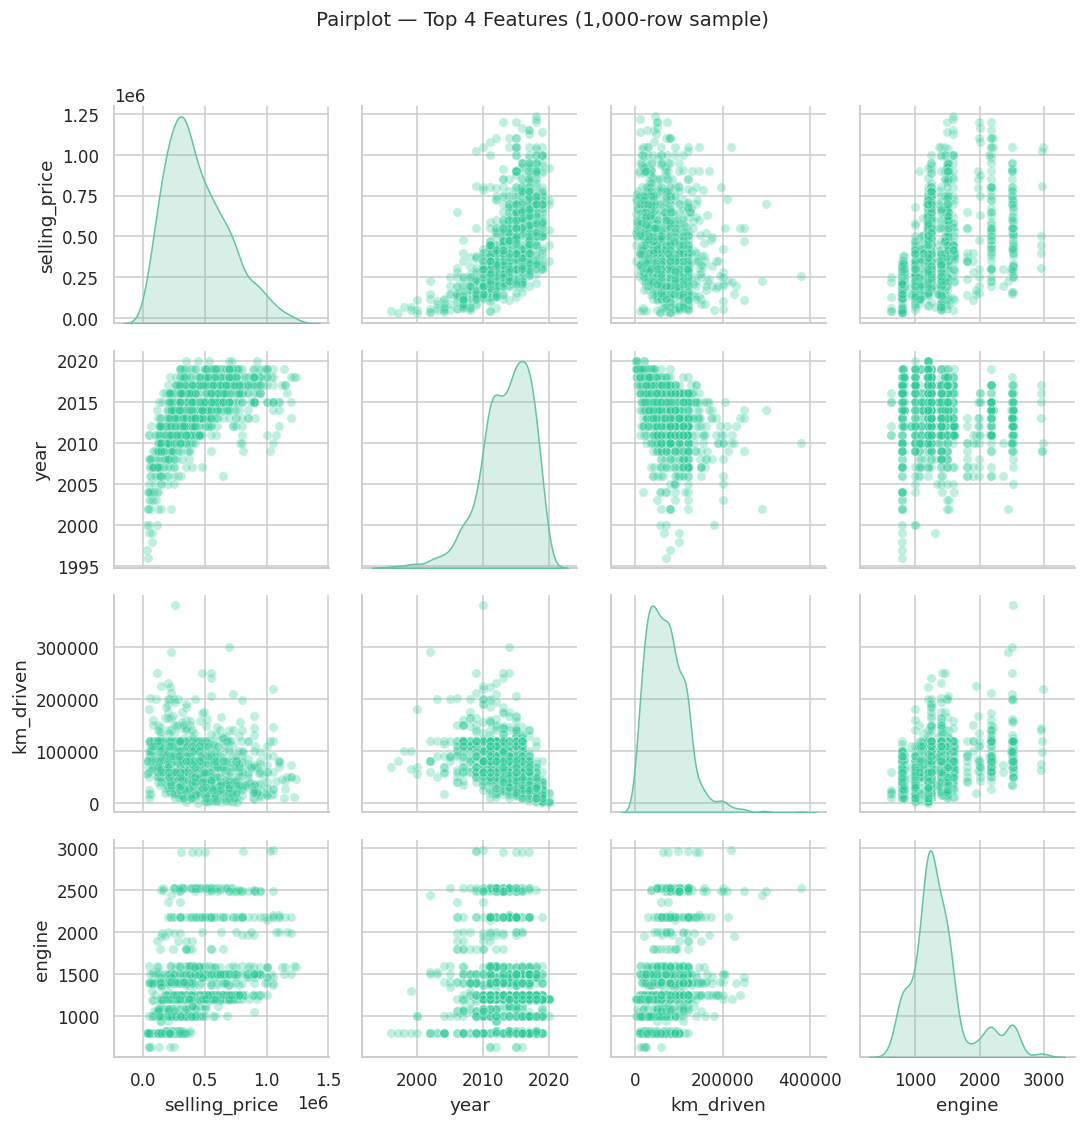

In [17]:
top4 = ['selling_price', 'year', 'km_driven', 'engine']

g = sns.pairplot(
    df[top4].sample(1000, random_state=42),
    diag_kind='kde',
    plot_kws={'alpha': 0.3, 'color': '#2ECB9B'},
)
g.fig.suptitle('Pairplot — Top 4 Features (1,000-row sample)', y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig(f'{IMAGES_DIR}/pairplot.png', bbox_inches='tight')
plt.show()


**Insight**
- The `selling_price` vs `year` panel makes the positive relationship from the previous section visually obvious — the point cloud fans upward and to the right.
- `km_driven` is itself right-skewed, with most cars under 100,000 km and a long tail beyond that.

## 8. Correlation Analysis <a id='8'></a>

Correlation with selling_price (sorted):
year                  0.63
max_power             0.55
engine                0.38
seats                 0.26
mileage(km/ltr/kg)    0.08
km_driven            -0.20
Name: selling_price, dtype: float64


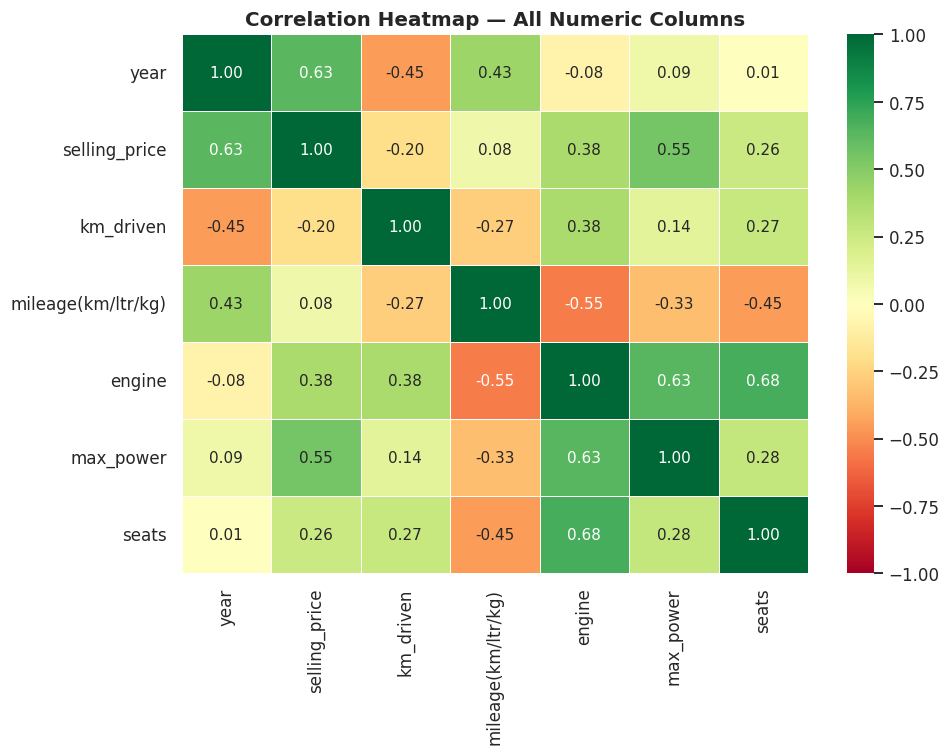

In [18]:
num_df = df.select_dtypes(include='number').drop(columns=['price_log'])
corr = num_df.corr()
corr_sp = corr['selling_price'].drop('selling_price').sort_values(ascending=False)

plt.figure(figsize=(9, 7))
sns.heatmap(
    corr,
    annot=True, fmt='.2f',
    cmap='RdYlGn', center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    annot_kws={'size': 10}
)
plt.title('Correlation Heatmap — All Numeric Columns', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{IMAGES_DIR}/correlation_heatmap.png', bbox_inches='tight')
plt.show()

print('Correlation with selling_price (sorted):')
print(corr_sp.round(2))


**Insight**
- `year` (0.63) and `max_power` (0.55) are the two strongest individual predictors of `selling_price` in this dataset.
- `engine` (0.38) and `seats` (0.26) are moderately positive; `km_driven` (-0.20) is moderately negative.
- `mileage(km/ltr/kg)` is almost uncorrelated with price (0.08) — counterintuitively, fuel-efficient cars are not reliably cheaper or pricier.
- `engine` and `seats` are themselves strongly correlated (0.68), as expected — bigger engines tend to go into bigger, higher-capacity vehicles.

## 9. Outlier Detection <a id='9'></a>

In [19]:
def iqr_bounds(series):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    return q1 - 1.5 * iqr, q3 + 1.5 * iqr

# Confirm that the IQR-based cleaning in Section 5 worked, and check whether
# any other numeric column still has a meaningful share of statistical outliers.
for col in ['selling_price', 'km_driven', 'engine', 'mileage(km/ltr/kg)']:
    low, high = iqr_bounds(df[col])
    n_outliers = ((df[col] < low) | (df[col] > high)).sum()
    pct = n_outliers / len(df) * 100
    print(f'{col:20s} IQR bounds: [{low:>12,.0f}, {high:>12,.0f}]  ->  {n_outliers:4d} outliers ({pct:4.1f}%)')


selling_price        IQR bounds: [    -275,000,    1,125,000]  ->    74 outliers ( 1.2%)
km_driven            IQR bounds: [     -50,000,      190,000]  ->   159 outliers ( 2.5%)
engine               IQR bounds: [         743,        1,951]  ->   934 outliers (14.6%)
mileage(km/ltr/kg)   IQR bounds: [           9,           31]  ->    17 outliers ( 0.3%)


**Insight**
- The Section 5 cleaning worked as intended: `selling_price` now has only 1.2% statistical outliers left (down from a much larger share before the IQR-based cap), and `km_driven` sits at a modest 2.5%.
- `engine` shows a surprisingly high 14.6% — but this isn't dirty data. It reflects real market segmentation: small-engine hatchbacks and large-engine SUVs are both common, so the distribution is naturally multi-modal rather than a single bell curve, and the IQR method flags the smaller segment's edge as "outliers" even though they're valid listings.
- `mileage(km/ltr/kg)` is the cleanest feature of all, with only 0.3% flagged.

## 10. Key Insights & Conclusion <a id='10'></a>

### Summary

- **Price is right-skewed.** Most used cars in this dataset sell between ₹150,000 and ₹650,000, with a median of ₹400,000; a handful of premium listings were removed during cleaning (via the IQR method) to keep the analysis representative of the typical market.
- **`year` is the single strongest price driver** (corr = 0.63), followed by **`max_power`** (corr = 0.55) and **`engine` size** (corr = 0.38) — newer, more powerful cars sell for more, unsurprisingly.
- **Distance driven has a moderate negative effect** (corr = -0.20) on price, while **fuel efficiency barely matters** (corr = 0.08).
- **Ownership history matters a lot:** average price drops by roughly half between a first-owner car and a fourth-owner one.
- **Diesel commands a premium** over Petrol, CNG, and LPG, largely because diesel is more common in larger vehicle segments.
- **Maruti and Hyundai dominate** the used-car market by listing volume, together accounting for roughly half of all cars in the dataset.

### Future Improvements

- Engineer a `car_age` feature (`current_year - year`) for a more interpretable version of the strongest predictor.
- Split `name` into separate `brand` and `model` columns (brand is already extracted) to enable model-level comparisons.
- Build a baseline regression model (e.g. Linear Regression or Random Forest) using `year`, `max_power`, `engine`, `km_driven`, `fuel`, and `owner` to predict `selling_price`, and compare its error against simply guessing the median.
- Investigate the `engine` column's multi-modal distribution by segmenting listings into vehicle classes (hatchback / sedan / SUV).